In [1]:
from tqdm import trange
import add_sys_path
add_sys_path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import csv
import pandas as pd
from scipy.interpolate import RegularGridInterpolator
import os
from mpl_toolkits.axes_grid1 import AxesGrid
from matplotlib.collections import LineCollection
from libs.interp import interp_traj



cyc = "AC3A" # "AC3A"

region = 0

if cyc != "AC3A" :
    region = 0

if region == 1:
    region_name = "PV zonal band"
elif region == 2:
    region_name = "Bent back front"
else :
    region_name = ""

txt_title = cyc
txt_save = ""

local = True

if cyc == 'AC3A' :
    niter=4
    dt_traj=0.5
    Nhor= 48#20
    Np=21 #11
    dataset = "era5_forecasts_1608T14_-15E-33E_78N-66.0N_750-960hPa" #"era5_forecasts_1608T14_5E-25E_78N-73.0N_850-960hPa"

    days = "15a16"
    loc = '65N-86N'
    time_ini=  '2022-08-16T14'
    long_min = -20
    long_max = 40
    lat_min = 66
    lat_max = 78
    level_min = 1000
    level_max = 700
    ini_time_step = 19
    h0 = 14 #9 #intial hour
    traj_duration = 19
    txt_title = f"{region_name} - {cyc}"
    txt_save = f"_{region_name.replace(' ', '_')}"

elif cyc =='AC3B' :
    niter=4
    dt_traj=0.5
    Nhor=40
    Np=21
    dataset = "era5_forecasts_1908T14_-10E-30E_89N-79.0N_750-960hPa"
    days = "17a19"
    loc = '74N-90N'
    time_ini= '2022-08-19T14'
    long_min = -15 #-20
    long_max = 80
    lat_min = 78 #65
    lat_max = 88

    level_min = 1000
    level_max = 800
    ini_time_step = 43 #31 #15 #7 #Initial time step of the trajectory 15 #
    h0 = 14 #intial hour
    lon_min_1 = -30
    lon_max_1 = 120
    lat_min_1 = 75
    lat_max_1 = 89.9
    traj_duration  =24

elif cyc == 'AC4' :
    niter=4
    dt_traj=0.5
    Nhor=40 #15
    Np=21
    dataset = "era5_forecasts_2308T09_10E-50E_80N-70.0N_750-960hPa" #"era5_forecasts_2308T09_25E-40E_78.5N-74.75N_850-960hPa"
    days = "22"
    loc = '65N-86N'
    time_ini=  '2022-08-23T09'
    long_min = 0
    long_max = 60
    lat_min = 67
    lat_max = 82
    level_min=1000
    level_max=800
    ini_time_step = 15 #31 #15 #7 #Initial time step of the trajectory 15 #
    h0 =9 #intial hour

if cyc == 'AC3A' :
    lon_min_3d = -30
    lon_max_3d = 40
    lat_max_3d = 85
    lat_min_3d = 65
elif cyc =='AC3B' :
    lon_min_3d = -30
    lon_max_3d = 70
    lat_max_3d = 88
    lat_min_3d = 78
elif cyc =='AC4' :
    lon_min_3d = 10
    lon_max_3d = 60
    lat_max_3d = 80
    lat_min_3d = 70

root_input = "/data/nchiab/PV"

if local :
    root_input = "/media/chabranoo/LaCie/PhD"



# path_plots = f"{root_input}/Generated_data/plots/era5_forecasts/Trajectories/{dataset}"
#
# if region != 0 :
#     path_plots = f"{root_input}/Generated_data/plots/era5_forecasts/Trajectories/{dataset}/{region_name}"

# os.makedirs(f'{path_plots}/indiv', exist_ok=True)
#
# os.makedirs(f'{path_plots}/heating_dominant', exist_ok=True)
# os.makedirs(f'{path_plots}/friction_dominant', exist_ok=True)
#
# os.makedirs(f'{path_plots}/rad_heating_dominant', exist_ok=True)
# os.makedirs(f'{path_plots}/latent_heating_dominant', exist_ok=True)



['/snap/pycharm-professional/604/plugins/python-ce/helpers/jupyter_debug', '/home/chabranoo/PycharmProjects/PhD/scripts/article_dynamics/AC3A/..', '/home/chabranoo/PycharmProjects/PhD/scripts/article_dynamics/AC3A/../..', '/home/chabranoo/PycharmProjects/PhD/scripts/article_dynamics/AC3A/../../..', '/home/chabranoo/PycharmProjects/PhD/scripts/article_dynamics/AC3A/../../../..', '/snap/pycharm-professional/604/plugins/python-ce/helpers/pydev', '/home/chabranoo/PycharmProjects/PhD', '/home/chabranoo/miniconda3/envs/classic/lib/python312.zip', '/home/chabranoo/miniconda3/envs/classic/lib/python3.12', '/home/chabranoo/miniconda3/envs/classic/lib/python3.12/lib-dynload', '', '/home/chabranoo/miniconda3/envs/classic/lib/python3.12/site-packages']


In [2]:
modlev = True #weither we are working with data in level model. Now it is by default True

hPa_pres = False  #weither the real pressure in the case of model levels (usually 'pres') are in hPa or not

P0 = 100000

if hPa_pres :
    P0 = 1000

name_p = 'P'

path_traj = f'{root_input}/Generated_data/data/era5_forecasts/Trajectories/{dataset}/Traj_time_step_{ini_time_step}_{traj_duration}h_dt{dt_traj}_niter{niter}_Nhor{Nhor}_Np{Np}.nc'
#path_traj = f'{root_input}/Generated_data/data/Trajectories/{dataset}/Traj_time_step_31_PM_model_levels.nc'
traj_ini = xr.open_dataset(path_traj)

dt = traj_ini['time'].isel(n_seeds=0, time_ind=0).data - traj_ini['time'].isel(n_seeds=0, time_ind=1).data
duration = traj_ini['time'].isel(n_seeds=0, time_ind=0).data - traj_ini['time'].isel(n_seeds=0, time_ind=-1).data
duration = 12
t_list = np.linspace(h0, h0 - duration, int(duration / dt) + 1, endpoint=True)

path_plots = f"{root_input}/Generated_data/plots/era5_forecasts/Trajectories/{dataset}/{duration}h/"

os.makedirs(path_plots, exist_ok=True)

In [3]:

#var_pv = 'pv'
#path_PV =f'{root_input}/Generated_data/data/era5_forecasts/PV/ERA5_forecasts_u_v_w_temp_PV_pres_all_levels_2022-08-{days}_{loc}.nc'
#path_PV =f'{root_input}/Generated_data/data/PV/ERA5_forecasts/ERA5_U_V_W_TEMP_PV_PM_all_levels_2022-08-15a16_50N-90N.nc'
path_data = f'{root_input}/Generated_data/data/era5_forecasts/ERA5_forecasts_all_pv_variables_all_levels_2022-08-{days}_{loc}.nc'
path_data_pressure =  f'{root_input}/Generated_data/data/era5_forecasts/ERA5_forecasts_all_pv_variables_700-1000hPa_per10hPa_2022-08-{days}_{loc}.nc'


In [4]:

if cyc =='AC3B' : #in order to remove the point at 90°N (divergence in PV)
    all_data = xr.open_dataset(path_data).sel(longitude = slice(lon_min_1, lon_max_1)).sel(latitude = slice(lat_max_1, lat_min_1))
    all_data_pressure = xr.open_dataset(path_data_pressure).sel(longitude = slice(lon_min_1, lon_max_1)).sel(latitude = slice(lat_max_1, lat_min_1)).rename({"plev":"level"})
    Sp  = xr.open_dataset(f'{root_input}/Data/era5_forecasts/ERA5_SP_2022-08-{days}_{loc}.nc').sel(longitude = slice(lon_min_1, lon_max_1)).sel(latitude = slice(lat_max_1, lat_min_1))
else :
    all_data = xr.open_dataset(path_data)
    all_data_pressure = xr.open_dataset(path_data_pressure).rename({"plev":"level"})
    Sp  = xr.open_dataset(f'{root_input}/Data/era5_forecasts/ERA5_SP_2022-08-{days}_{loc}.nc')



all_data = all_data.sel(latitude=slice(None, None, -1))#.sel(level = slice(100000, 70000))

all_data_pressure = all_data_pressure.where(all_data_pressure['level'] < Sp['sp'], np.nan)


all_data_pressure = all_data_pressure.assign_coords(level=all_data_pressure.level / 100)

# update units metadata
all_data_pressure.level.attrs["units"] = "hPa"


# PV = all_data['PV_1'] + all_data['PV_2'] + all_data['PV_3']#.isel(time = slice(19, 32)).sel(latitude = slice(lat_max, lat_min), longitude = slice(long_min, long_max), level = slice(level_max, level_min))
PV_pressure = all_data_pressure['PV_1'] +  all_data_pressure['PV_2'] +   all_data_pressure['PV_3']

In [5]:
time = np.arange(0, np.size(all_data['time']))

In [6]:

#traj_era5 = xr.open_dataset(path_traj_era5)
#data_lmdz = xr.open_dataset(path_lmdz)
n_date = all_data['time'].isel(time = int(traj_ini['time'].isel(n_seeds = 0,time_ind = 0)))
date = f'{pd.to_datetime(n_date.data).year}-0{pd.to_datetime(n_date.data).month}-{pd.to_datetime(n_date.data).day}'

In [7]:

n_list = traj_ini['n_seeds'].data
n_list = []

#
# n_region1_list = []
# n_region2_list = []


n_list = []


# for i in traj_ini['n_seeds'].to_numpy() :
#     if traj_ini.isel(time_ind=time_ind0).sel(n_seeds=i)['P'] >= 850 * 100:
#         if traj_ini.isel(time_ind=time_ind0).sel(n_seeds=i)['P'] <= 950 * 100 :
#             if traj_ini.isel(time_ind=time_ind0).sel(n_seeds=i)['lat'] <= 72.8:
#                 if traj_ini.isel(time_ind=time_ind0).sel(n_seeds=i)['lat'] >= 72:
#                     if traj_ini.isel(time_ind = time_ind0).sel(n_seeds = i)['lon'] > 6 :
#                         if traj_ini.isel(time_ind=time_ind0).sel(n_seeds=i)['lon'] < 11:
#                         #n_region1_list.append(i)
#                             n_list.append(i)
    # if traj_ini.isel(time_ind = 0).sel(n_seeds = i)['lon'] <= 21 or traj_ini.isel(time_ind = 0).sel(n_seeds = i)['lat'] <= 76 :
    #     # if traj_ini.isel(time_ind = 0).sel(n_seeds = i)['lon'] <= 23 :
    #if traj_ini.isel(time_ind = 0).sel(n_seeds = i)['lat'] <= 87.2 :
    # if traj_ini['pv'].sel(n_seeds = i).isel(time_ind = 0) > traj_ini['pv'].sel(n_seeds = i).isel(time_ind = -1) :
    #         if traj_ini.isel(time_ind = time_ind0).sel(n_seeds = i)['lat'] > 72 :
    #             # if traj_ini.isel(time_ind = 0).sel(n_seeds = i)['lon'] < 20 :
    #             #     if traj_ini.isel(time_ind=0).sel(n_seeds=i)['lat'] > 74.5 :
    #             #             n_list.append(i)
    #
    #             if traj_ini.isel(time_ind = time_ind0).sel(n_seeds = i)['lon'] > -3 :
    #                 #n_region1_list.append(i)
    #                 n_list.append(i)
    #             elif traj_ini.isel(time_ind = time_ind0).sel(n_seeds = i)['lat'] < 73 :
    #              #   n_region2_list.append(i)
    #                 n_list.append(i)
    #
    #         elif traj_ini.isel(time_ind = time_ind0).sel(n_seeds = i)['lon'] < 1 :
    #             if traj_ini.isel(time_ind = time_ind0).sel(n_seeds = i)['lat'] > 67 :
    #              #   n_region2_list.append(i)
    #                 n_list.append(i)

from libs.traj import is_in_region

n_list = is_in_region(traj_ini, cyc)


traj = traj_ini.sel(n_seeds = n_list).sel(time_ind = slice(0, int(duration  / dt + 1)))



print(f'Number of trajectories : {len(n_list)}')

Number of trajectories : 1402


In [8]:
#n_point = []

# isnan_P = ~np.isnan(traj['P'])
#
# n_point = np.sum(isnan_P, axis = 0)
#
#
#
#
#
# dpvdt_traj = -(traj['pv'].differentiate('time_ind') /  (dt * 3600) * 1e6) # pvu / s
# #rayon de la terre
# mean_traj = traj.mean('n_seeds')
#
# def theta_f(T, P, P0 = 1000) :
#     return T * (P0 / P)**0.286
# theta_traj = theta_f(traj['temp'], traj['P'], P0 = 100000)

pres = all_data["pres"]#.sel(level=slice(None, None, -1))

# PV_dot_heating =all_data['PV_dot_heating_1'] + all_data['PV_dot_heating_2'] + all_data['PV_dot_heating_3']
# PV_dot_friction =all_data['PV_dot_friction_1'] + all_data['PV_dot_friction_2'] + all_data['PV_dot_friction_3']

In [9]:
# PV_dot = PV_dot_heating + PV_dot_friction
#
# PV_dot_list = np.full((np.size(traj['n_seeds']),int(duration / dt) + 1), np.nan)
# PV_dot_heating_list = np.full((np.size(traj['n_seeds']),int(duration / dt) + 1), np.nan)
# PV_dot_friction_list = np.full((np.size(traj['n_seeds']),int(duration / dt) + 1), np.nan)
#


# PV_dot_friction_list = np.full((np.size(traj['n_seeds']),int(duration / dt) + 1), np.nan)
# PV_dot_heating_SWRCS_list = np.full((np.size(traj['n_seeds']),int(duration / dt) + 1), np.nan)
# PV_dot_heating_LWRCS_list = np.full((np.size(traj['n_seeds']),int(duration / dt) + 1), np.nan)

# n_seeds_pos = []
PV_dot_friction_list = np.full((np.size(traj['n_seeds']),int(duration / dt) + 1), np.nan)


PV_dot_friction =all_data['PV_dot_friction_1'] + all_data['PV_dot_friction_2'] + all_data['PV_dot_friction_3']

time = np.arange(0,all_data['u'].shape[0])
level = all_data['level'].to_numpy()
lat = all_data['latitude'].to_numpy()
lon = all_data['longitude'].to_numpy()

n_seeds_heating = []
n_seeds_heating_latent = []
n_seeds_heating_rad = []
n_seeds_friction = []

for i in trange(np.size(traj['n_seeds'].to_numpy()), desc="Processing"):
    

    PV_dot_friction_interp =  interp_traj(i, PV_dot_friction.to_numpy(), lat, lon, level, time, traj, varlev='m')#, hPa = True)
    PV_dot_friction_list[i] =PV_dot_friction_interp

    
   
#
#



Processing: 100%|██████████| 1402/1402 [00:01<00:00, 1038.59it/s]


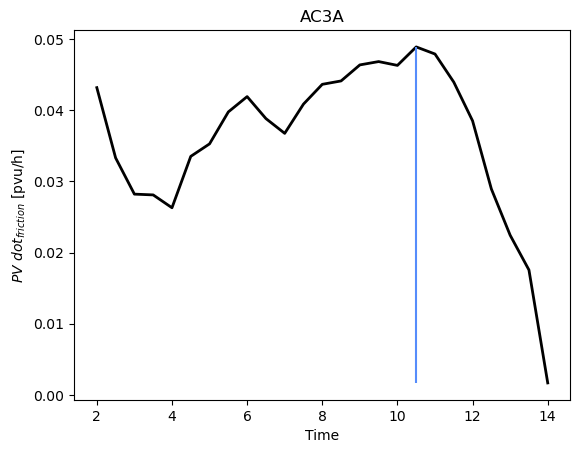

In [10]:

PV_dot_heating_lat_mean = np.nanmean(PV_dot_friction_list, axis = 0)
time_ind_max = np.argwhere(PV_dot_heating_lat_mean == np.max(PV_dot_heating_lat_mean))[0][0]




PV_dot_heating_LWR_mean = np.nanmean(PV_dot_friction_list, axis = 0)
# time_ind = np.argwhere(PV_dot_heating_LWR_mean == np.max(PV_dot_heating_LWR_mean))[0][0]




fig0 = plt.figure(0)



plt.plot(t_list, (np.nanmean(PV_dot_friction_list, axis = 0) )* 1e6 * 3600, color = 'black', linewidth = 2)
plt.vlines(t_list[time_ind_max], ymin = np.nanmin(PV_dot_heating_LWR_mean)* 1e6 * 3600, ymax = np.nanmax(PV_dot_heating_LWR_mean)* 1e6 * 3600 )
plt.xlabel('Time')
plt.ylabel(r'$PV \ dot_{friction}$ [pvu/h]')
plt.title(f'{cyc}')
plt.show()
#

2022-08-16T07


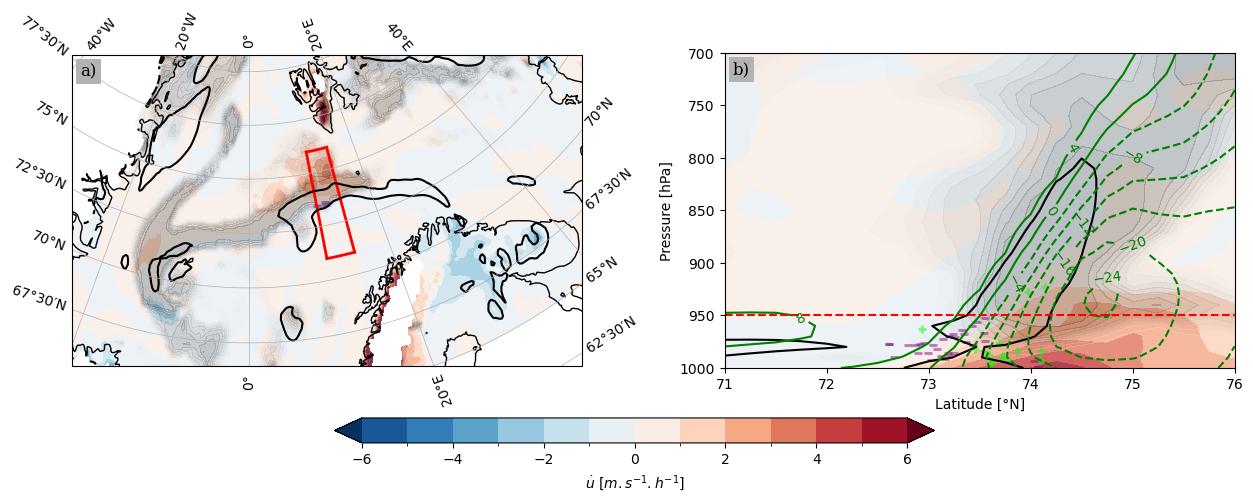

In [22]:


# Create colormap
s = None #30
linewidths_m = 2
linewidths_p = 2
# newcmp = ListedColormap(pv_data_norm, name = 'cmap_pv')

# pv_lev =  [0,.5,1,1.5,2,3,5,8,10]
lon_min_cs = 11#+ 19#0 #0#28 #
lon_max_cs = 15 # + 19 #20 # 20  #50 #
lat_min_cs = 71
lat_max_cs = 76
# time_ind = 2

# lon_min_cs = 27 # 6 +4#0 #0#28 #
# lon_max_cs = 29 # 10+4  #20 # 20  #50 #
# lat_min_cs = 70.5
# lat_max_cs = 75.5
# time_ind =2

kappa = 0.286
lev_min_cs = 1050
lev_max_cs = 700

time_ind = 14
time_ind0 = 14

d0 = pd.to_datetime(n_date.data).day
h0 = pd.to_datetime(n_date.data).hour

from libs.traj import date_from_time_ind

time_cs = date_from_time_ind(time_ind, h0, d0)

print(time_cs)


threshold = 0.1


Fx = all_data_pressure['Fx'] * 3600
u = all_data_pressure['u']

fig = plt.figure(figsize = (15, 5))

ax1 = plt.subplot(1,2,1, projection=ccrs.NorthPolarStereo())
 # Cross sections
#12.4242
pres = 950

ax1.coastlines()
ax1.set_global()
ax1.set_extent([long_min, long_max, lat_min, lat_max], ccrs.PlateCarree())
gl = ax1.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.bottom_labels = False
gl.right_labels = False

# Plot the unmasked topo data


# Add other data variables
im = Fx.sel(time=time_cs, level= pres, method = 'nearest').plot.contourf(
    ax=ax1, add_colorbar=False, extend = 'both', transform=ccrs.PlateCarree() , levels = np.arange(-6,6.1,1)) #

# traj0 = traj.isel(time_ind = time_ind).sel(n_seeds =n_seeds_heating_lwr)
traj1 = traj.isel(time_ind = time_ind)#.sel(n_seeds =n_seeds_heating_lwr_neg)

## Select only points with significant LWR heating
PV_dot_heating_friction0 = PV_dot_friction_list[:, time_ind0]
# traj0 = traj0.where(PV_dot_heating_friction0 * 3600 * 1e6 >= threshold )
#
# traj0 = traj0.where(traj0['P'] <= (pres + 10) * 100 )
# traj0 = traj0.where(traj0['P'] >= (pres - 10) * 100 )
#
# # ax1.scatter(traj0['lon'], traj0['lat'], c = PV_dot_friction_list[n_seeds_heating_lwr, time_ind] * 3600 * 1e6, cmap = 'BrBG', vmin = -1, vmax = 1,  marker = '+', linewidths = 1, transform=ccrs.PlateCarree())#, alpha = 0.3)
# ax1.scatter(traj0['lon'], traj0['lat'], color = 'black', marker = '+', linewidths = 1, transform=ccrs.PlateCarree(), alpha = 0.5)

traj0 = traj1.where(PV_dot_heating_friction0 * 3600 * 1e6 >= threshold  )

traj0 = traj0.where(traj0['lon'] >= lon_min_cs )
traj0 = traj0.where(traj0['lon'] <= lon_max_cs )
traj0 = traj0.where(traj0['lat'] >= lat_min_cs )
traj0 = traj0.where(traj0['lat'] <= lat_max_cs )
traj0 = traj0.where(traj0['P'] >= (pres - 10) * 100 )
traj0 = traj0.where(traj0['P'] <= (pres + 10) * 100 )

# ax1.scatter(traj0['lon'], traj0['lat'], color = 'black',  transform=ccrs.PlateCarree(), alpha = 0.5, s = s, linewidths = linewidths_p)#, alpha = 0.3)

ax1.scatter(traj0['lon'], traj0['lat'], color = 'lime', marker = '+', transform=ccrs.PlateCarree(), alpha = 0.5, s = s, linewidths = linewidths_p) #, alpha = 0.3)

traj0 = traj1.where(PV_dot_heating_friction0 * 3600 * 1e6 <= -threshold  )
traj0 = traj0.where(traj0['P'] >= (pres - 10) * 100 )
traj0 = traj0.where(traj0['P'] <= (pres + 10) * 100 )
traj0 = traj0.where(traj0['lon'] >= lon_min_cs )
traj0 = traj0.where(traj0['lon'] <= lon_max_cs )
traj0 = traj0.where(traj0['lat'] >= lat_min_cs )
traj0 = traj0.where(traj0['lat'] <= lat_max_cs )

ax1.scatter(traj0['lon'], traj0['lat'], color = 'purple', marker = '_', transform=ccrs.PlateCarree(), alpha = 0.5, s = s, linewidths = linewidths_m)#, alpha = 0.3)
#œ
#
ax1.plot(np.linspace(lon_min_cs, lon_min_cs, 10), np.linspace(lat_min_cs, lat_max_cs, 10), color = 'red', transform=ccrs.Geodetic(), linewidth = 2)
ax1.plot(np.linspace(lon_min_cs, lon_max_cs, 10), np.linspace( lat_max_cs, lat_max_cs, 10), color = 'red', transform=ccrs.Geodetic(), linewidth = 2)
ax1.plot(np.linspace( lon_max_cs, lon_max_cs, 10), np.linspace( lat_max_cs,lat_min_cs, 10), color = 'red', transform=ccrs.Geodetic(), linewidth = 2)
ax1.plot(np.linspace(lon_max_cs, lon_min_cs, 10), np.linspace( lat_min_cs, lat_min_cs, 10), color = 'red', transform=ccrs.Geodetic(), linewidth = 2)

clouds = all_data_pressure['cldr'].sel(time=time_cs, level= pres, method = 'nearest' ).plot.contourf(
    ax=ax1, add_colorbar=False,levels = np.arange(0.1,1.1,0.1), alpha = 0.2, cmap = 'Greys', transform=ccrs.PlateCarree() )

Pv_contours = (PV_pressure * 1e6).sel(time=time_cs, level= pres, method = 'nearest'  ).plot.contour(
    ax=ax1, add_colorbar=False, levels = [2], colors = 'black', transform=ccrs.PlateCarree())  # levels =[-0.8, 0, 0.8, 1.6, 3.2, 4.8, 5.6])# )#, cmap = 'plasma')

# ax.clabel(Pv_contours)

# clouds = all_data_pressure['cldr'].sel(time=time_cs, method='nearest').sel(longitude=slice(lon_min_cs, lon_max_cs),    level=slice(lev_min_cs, lev_max_cs),
#                                                      latitude=slice(lat_max_cs, lat_min_cs)).mean(
#     'longitude').plot.contourf(
#     ax=ax, add_colorbar=False, levels = np.arange(0.1,1.1,0.1), alpha = 0.2, cmap = 'Greys')

# ax.set_yticks(yticks)
# ax.set_yticklabels([f"{tick} hPa" for tick in yticks])


# plt.gca().invert_yaxis()

ax1.set_title(f'')
ax1.set_ylabel('Pressure [hPa]')





#################"

ax2 = plt.subplot(1,2,2)


# Add other data variables
# Add other data variables
im = Fx.sel(time=time_cs, method = 'nearest').sel(longitude=slice(lon_min_cs, lon_max_cs),    level=slice(lev_min_cs, lev_max_cs),
                                                     latitude=slice(lat_max_cs, lat_min_cs)).mean(
    'longitude', skipna = False).plot.contourf(
    ax=ax2, add_colorbar=False, extend = 'both',levels = np.arange(-6, 6.1, 1))#  cmap = 'coolwarm') # levels = np.arange(-0.0003,0.00031,0.00005),



Pv_contours = (PV_pressure * 1e6).sel(time=time_cs, method = 'nearest' ).sel(longitude=slice(lon_min_cs, lon_max_cs),    level=slice(lev_min_cs, lev_max_cs),
                                                     latitude=slice(lat_max_cs, lat_min_cs)).mean(
    'longitude', skipna = False).plot.contour(
    ax=ax2, add_colorbar=False,levels=[2], extend = 'both', colors = 'black')  # levels =[-0.8, 0, 0.8, 1.6, 3.2, 4.8, 5.6])# )#, cmap = 'plasma')

# ax.clabel(Pv_contours)

clouds = all_data_pressure['cldr'].sel(time=time_cs, method='nearest').sel(longitude=slice(lon_min_cs, lon_max_cs),    level=slice(lev_min_cs, lev_max_cs),
                                                     latitude=slice(lat_max_cs, lat_min_cs)).mean(
    'longitude', skipna = False).plot.contourf(
    ax=ax2, add_colorbar=False, levels = np.arange(0.1,1.1,0.1), alpha = 0.2, cmap = 'Greys')



CSu = u.sel(time=time_cs,  method='nearest').sel(longitude=slice(lon_min_cs,lon_max_cs),level=slice(lev_min_cs, lev_max_cs),
                                                                    latitude=slice(lat_max_cs, lat_min_cs)).mean('longitude', skipna = False).plot.contour(ax=ax2,
                                                                                                                  add_colorbar=False,
                                                                                                                  colors='green', levels=  np.arange(-24,26,4))

ax2.hlines(pres, lat_min_cs, lat_max_cs, linestyle = 'dashed', color = 'red')
ax2.clabel(CSu)

# traj0 = traj.isel(time_ind = time_ind).sel(n_seeds =n_seeds_heating_lwr)
traj1 = traj.isel(time_ind = time_ind)#.sel(n_seeds =n_seeds_heating_lwr_neg)
PV_dot_heating_friction0 = PV_dot_friction_list[:, time_ind0]
# traj0 = traj0.where(PV_dot_heating_friction0 * 3600 * 1e6 >= threshold )
# traj0 = traj0.where(traj0['lon'] > lon_min_cs )
# traj0 = traj0.where(traj0['lon'] < lon_max_cs )
# traj0 = traj0.where(traj0['lat'] >= lat_min_cs )
# traj0 = traj0.where(traj0['lat'] <= lat_max_cs )
# ax2.scatter(traj0['lat'], traj0['P'] / 100, color = 'black', marker = '+', linewidths = 1, alpha = 0.5)#, alpha = 0.3)

traj0 = traj1.where(PV_dot_heating_friction0 * 3600 * 1e6 >=  threshold )

traj0 = traj0.where(traj0['lon'] >= lon_min_cs )
traj0 = traj0.where(traj0['lon'] <= lon_max_cs )
traj0 = traj0.where(traj0['lat'] >= lat_min_cs )
traj0 = traj0.where(traj0['lat'] <= lat_max_cs )
# ax2.scatter(traj0['lat'], traj0['P'] / 100, color = 'black', marker = ".", alpha = 0.5, s = s, linewidths = linewidths_p)#, alpha = 0.3)
ax2.scatter(traj0['lat'], traj0['P'] / 100, color = 'lime', marker = '+',  alpha = 0.5, s = s, linewidths = linewidths_p)#, alpha = 0.3)

traj0 = traj1.where(PV_dot_heating_friction0 * 3600 * 1e6 <= -threshold  )
traj0 = traj0.where(traj0['lon'] >= lon_min_cs )
traj0 = traj0.where(traj0['lon'] <= lon_max_cs )
traj0 = traj0.where(traj0['lat'] >= lat_min_cs )
traj0 = traj0.where(traj0['lat'] <= lat_max_cs )

ax2.scatter(traj0['lat'], traj0['P'] / 100, color = 'purple', marker = '_',  alpha = 0.5, s = s, linewidths = linewidths_m)#, alpha = 0.3)


ax2.invert_yaxis()
ax2.set_title(f'') #Latent heating - zonal mean {lon_min_cs}°E-{lon_max_cs}°E - {time_cs} - {cyc} {region_name}')
ax2.set_ylabel('Pressure [hPa]')
ax2.set_xlabel('Latitude [°N]')
gl = ax1.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.bottom_labels = False
gl.right_labels = False
cbar_ax = fig.add_axes([0.3, 0.1, 0.4, 0.05])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')#,label = 'Potential vorticity [pvu]')#, fontsize = 20)
cbar.set_label(r'$\dot{u}$ [$m.s^{-1}.h^{-1}$]')#, size = 20)
# cbar.ax.tick_params(labelsize=20)


label_list = ['a)', 'b)']
axs = [ax1, ax2]
for i in range(len(label_list)):
    axi = axs[i]
    axi.annotate(
        label_list[i],
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize='large', verticalalignment='top', fontfamily='serif',
        bbox=dict(facecolor='0.7', edgecolor='none', pad=3.0))


# plt.savefig(f'{path_plots}/lwr_posneg_article_ind{time_ind}_{dataset}_{cyc}.png', bbox_inches='tight')
plt.show()












2022-08-16T14


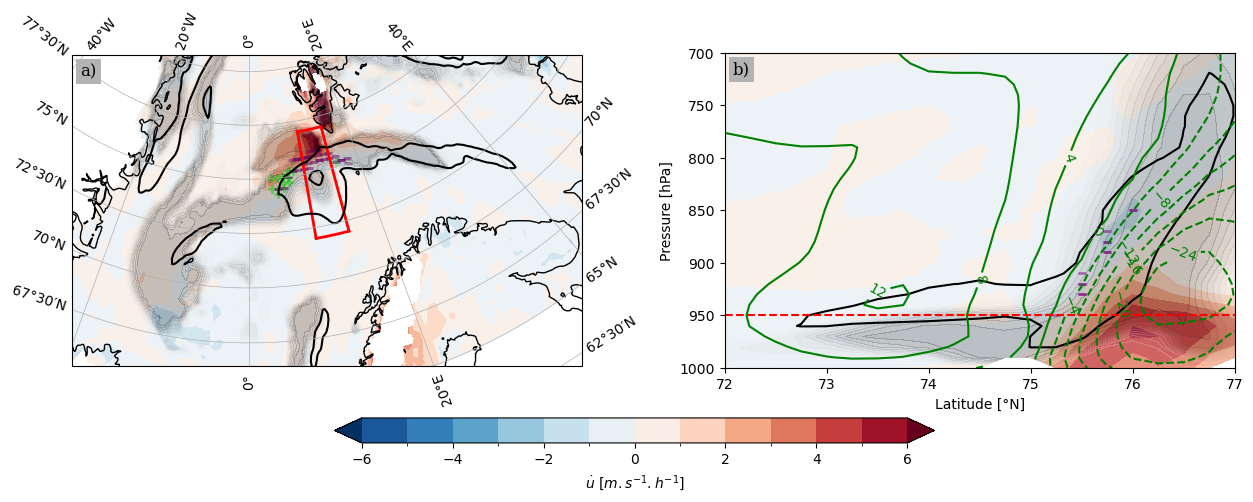

In [23]:

# Create colormap
s = None #30
linewidths_m = 2
linewidths_p = 2
# newcmp = ListedColormap(pv_data_norm, name = 'cmap_pv')

# pv_lev =  [0,.5,1,1.5,2,3,5,8,10]
# lon_min_cs_0 = 9 + 3 #+ 19#0 #0#28 #
# lon_max_cs_0 = 13 + 3# + 19 #20 # 20  #50 #
# lat_min_cs_0 = 72
# lat_max_cs_0 = 77

lon_min_cs_0 = 11 #+ 19#0 #0#28 #
lon_max_cs_0 = 15# + 19 #20 # 20  #50 #
lat_min_cs_0 = 71
lat_max_cs_0 = 75

# time_ind = 2
lon_min_cs = 10  #+ 19#0 #0#28 #
lon_max_cs = 15 # + 19 #20 # 20  #50 #
lat_min_cs = 72
lat_max_cs = 77
# lon_min_cs = 27 # 6 +4#0 #0#28 #
# lon_max_cs = 29 # 10+4  #20 # 20  #50 #
# lat_min_cs = 70.5
# lat_max_cs = 75.5
# time_ind =2

kappa = 0.286
lev_min_cs = 1050
lev_max_cs = 700

time_ind = 0
time_ind0 = 14

d0 = pd.to_datetime(n_date.data).day
h0 = pd.to_datetime(n_date.data).hour

from libs.traj import date_from_time_ind

time_cs = date_from_time_ind(time_ind, h0, d0)

print(time_cs)


threshold = 0.1


u = all_data_pressure['u']

fig = plt.figure(figsize = (15, 5))

ax1 = plt.subplot(1,2,1, projection=ccrs.NorthPolarStereo())
 # Cross sections
#12.4242
pres = 950

ax1.coastlines()
ax1.set_global()
ax1.set_extent([long_min, long_max, lat_min, lat_max], ccrs.PlateCarree())
gl = ax1.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.bottom_labels = False
gl.right_labels = False

# Plot the unmasked topo data


# Add other data variables
im = Fx.sel(time=time_cs, level= pres, method = 'nearest').plot.contourf(
    ax=ax1, add_colorbar=False, extend = 'both', transform=ccrs.PlateCarree() , levels = np.arange(-6,6.1,1)) #

# traj0 = traj.isel(time_ind = time_ind).sel(n_seeds =n_seeds_heating_lwr)
traj1 = traj.isel(time_ind = time_ind)#.sel(n_seeds =n_seeds_heating_lwr_neg)

## Select only points with significant LWR heating
PV_dot_heating_friction0 = PV_dot_friction_list[:, time_ind0]
# traj0 = traj0.where(PV_dot_heating_friction0 * 3600 * 1e6 >= threshold )
#
# traj0 = traj0.where(traj0['P'] <= (pres + 10) * 100 )
# traj0 = traj0.where(traj0['P'] >= (pres - 10) * 100 )
#
# # ax1.scatter(traj0['lon'], traj0['lat'], c = PV_dot_friction_list[n_seeds_heating_lwr, time_ind] * 3600 * 1e6, cmap = 'BrBG', vmin = -1, vmax = 1,  marker = '+', linewidths = 1, transform=ccrs.PlateCarree())#, alpha = 0.3)
# ax1.scatter(traj0['lon'], traj0['lat'], color = 'black', marker = '+', linewidths = 1, transform=ccrs.PlateCarree(), alpha = 0.5)

traj0 = traj1.where(PV_dot_heating_friction0 * 3600 * 1e6 >= threshold  )

traj01 = traj.isel(time_ind = time_ind0)


traj01 = traj01.where(PV_dot_heating_friction0 * 3600 * 1e6 >=  threshold )

traj0 = traj0.where(traj01['lon'] >= lon_min_cs_0 )
traj0 = traj0.where(traj01['lon'] <= lon_max_cs_0 )
traj0 = traj0.where(traj01['lat'] >= lat_min_cs_0 )
traj0 = traj0.where(traj01['lat'] <= lat_max_cs_0 )
# traj0 = traj0.where(traj01['P'] >= (pres - 10) * 100 )
# traj0 = traj0.where(traj01['P'] <= (pres + 10) * 100 )

# ax1.scatter(traj0['lon'], traj0['lat'], color = 'black',  transform=ccrs.PlateCarree(), alpha = 0.5, s = s, linewidths = linewidths_p)#, alpha = 0.3)

ax1.scatter(traj0['lon'], traj0['lat'], color = 'lime', marker = '+', transform=ccrs.PlateCarree(), alpha = 0.5, s = s, linewidths = linewidths_p) #, alpha = 0.3)

traj01 = traj.isel(time_ind = time_ind0)


traj01 = traj01.where(PV_dot_heating_friction0 * 3600 * 1e6 <=  - threshold )
traj0 = traj1.where(PV_dot_heating_friction0 * 3600 * 1e6 <= -threshold  )

traj0 = traj0.where(traj01['lon'] >= lon_min_cs_0 )
traj0 = traj0.where(traj01['lon'] <= lon_max_cs_0 )
traj0 = traj0.where(traj01['lat'] >= lat_min_cs_0 )
traj0 = traj0.where(traj01['lat'] <= lat_max_cs_0 )


# traj0 = traj0.where(traj01['P'] >= (pres - 10) * 100 )
# traj0 = traj0.where(traj01['P'] <= (pres + 10) * 100 )

ax1.scatter(traj0['lon'], traj0['lat'], color = 'purple', marker = '_', transform=ccrs.PlateCarree(), alpha = 0.5, s = s, linewidths = linewidths_m)#, alpha = 0.3)
#
#
ax1.plot(np.linspace(lon_min_cs, lon_min_cs, 10), np.linspace(lat_min_cs, lat_max_cs, 10), color = 'red', transform=ccrs.Geodetic(), linewidth = 2)
ax1.plot(np.linspace(lon_min_cs, lon_max_cs, 10), np.linspace( lat_max_cs, lat_max_cs, 10), color = 'red', transform=ccrs.Geodetic(), linewidth = 2)
ax1.plot(np.linspace( lon_max_cs, lon_max_cs, 10), np.linspace( lat_max_cs,lat_min_cs, 10), color = 'red', transform=ccrs.Geodetic(), linewidth = 2)
ax1.plot(np.linspace(lon_max_cs, lon_min_cs, 10), np.linspace( lat_min_cs, lat_min_cs, 10), color = 'red', transform=ccrs.Geodetic(), linewidth = 2)

clouds = all_data_pressure['cldr'].sel(time=time_cs, level= pres, method = 'nearest' ).plot.contourf(
    ax=ax1, add_colorbar=False,levels = np.arange(0.1,1.1,0.1), alpha = 0.2, cmap = 'Greys', transform=ccrs.PlateCarree() )

Pv_contours = (PV_pressure * 1e6).sel(time=time_cs, level= pres, method = 'nearest'  ).plot.contour(
    ax=ax1, add_colorbar=False, levels = [2], colors = 'black', transform=ccrs.PlateCarree())  # levels =[-0.8, 0, 0.8, 1.6, 3.2, 4.8, 5.6])# )#, cmap = 'plasma')

# ax.clabel(Pv_contours)

# clouds = all_data_pressure['cldr'].sel(time=time_cs, method='nearest').sel(longitude=slice(lon_min_cs, lon_max_cs),    level=slice(lev_min_cs, lev_max_cs),
#                                                      latitude=slice(lat_max_cs, lat_min_cs)).mean(
#     'longitude').plot.contourf(
#     ax=ax, add_colorbar=False, levels = np.arange(0.1,1.1,0.1), alpha = 0.2, cmap = 'Greys')

# ax.set_yticks(yticks)
# ax.set_yticklabels([f"{tick} hPa" for tick in yticks])


# plt.gca().invert_yaxis()

ax1.set_title(f'')
ax1.set_ylabel('Pressure [hPa]')





#################"

ax2 = plt.subplot(1,2,2)


# Add other data variables
# Add other data variables
im = Fx.sel(time=time_cs, method = 'nearest').sel(longitude=slice(lon_min_cs, lon_max_cs),    level=slice(lev_min_cs, lev_max_cs),
                                                     latitude=slice(lat_max_cs, lat_min_cs)).mean(
    'longitude', skipna = False).plot.contourf(
    ax=ax2, add_colorbar=False, extend = 'both',levels = np.arange(-6, 6.1, 1))#  cmap = 'coolwarm') # levels = np.arange(-0.0003,0.00031,0.00005),



Pv_contours = (PV_pressure * 1e6).sel(time=time_cs, method = 'nearest' ).sel(longitude=slice(lon_min_cs, lon_max_cs),    level=slice(lev_min_cs, lev_max_cs),
                                                     latitude=slice(lat_max_cs, lat_min_cs)).mean(
    'longitude', skipna = False).plot.contour(
    ax=ax2, add_colorbar=False,levels=[2], extend = 'both', colors = 'black')  # levels =[-0.8, 0, 0.8, 1.6, 3.2, 4.8, 5.6])# )#, cmap = 'plasma')

# ax.clabel(Pv_contours)

clouds = all_data_pressure['cldr'].sel(time=time_cs, method='nearest').sel(longitude=slice(lon_min_cs, lon_max_cs),    level=slice(lev_min_cs, lev_max_cs),
                                                     latitude=slice(lat_max_cs, lat_min_cs)).mean(
    'longitude', skipna = False).plot.contourf(
    ax=ax2, add_colorbar=False, levels = np.arange(0.1,1.1,0.1), alpha = 0.2, cmap = 'Greys')



CSu = u.sel(time=time_cs,  method='nearest').sel(longitude=slice(lon_min_cs,lon_max_cs),level=slice(lev_min_cs, lev_max_cs),
                                                                    latitude=slice(lat_max_cs, lat_min_cs)).mean('longitude', skipna = False).plot.contour(ax=ax2,
                                                                                                                  add_colorbar=False,
                                                                                                                  colors='green', levels=  np.arange(-24,26,4))

ax2.hlines(pres, lat_min_cs, lat_max_cs, linestyle = 'dashed', color = 'red')
ax2.clabel(CSu)

# traj0 = traj.isel(time_ind = time_ind).sel(n_seeds =n_seeds_heating_lwr)
traj1 = traj.isel(time_ind = time_ind)#.sel(n_seeds =n_seeds_heating_lwr_neg)
traj01 = traj.isel(time_ind = time_ind0)

PV_dot_heating_friction0 = PV_dot_friction_list[:, time_ind0]
traj01 = traj01.where(PV_dot_heating_friction0 * 3600 * 1e6 >=  threshold )
# traj0 = traj0.where(PV_dot_heating_friction0 * 3600 * 1e6 >= threshold )
# traj0 = traj0.where(traj0['lon'] > lon_min_cs )
# traj0 = traj0.where(traj0['lon'] < lon_max_cs )
# traj0 = traj0.where(traj0['lat'] >= lat_min_cs )
# traj0 = traj0.where(traj0['lat'] <= lat_max_cs )
# ax2.scatter(traj0['lat'], traj0['P'] / 100, color = 'black', marker = '+', linewidths = 1, alpha = 0.5)#, alpha = 0.3)

traj0 = traj1.where(PV_dot_heating_friction0 * 3600 * 1e6 >=  threshold )

traj0 = traj0.where(traj01['lon'] >= lon_min_cs_0 )
traj0 = traj0.where(traj01['lon'] <= lon_max_cs_0 )
traj0 = traj0.where(traj01['lat'] >= lat_min_cs_0 )
traj0 = traj0.where(traj01['lat'] <= lat_max_cs_0 )


traj0 = traj0.where(traj0['lon'] > lon_min_cs )
traj0 = traj0.where(traj0['lon'] < lon_max_cs )
traj0 = traj0.where(traj0['lat'] >= lat_min_cs )
traj0 = traj0.where(traj0['lat'] <= lat_max_cs )

# ax2.scatter(traj0['lat'], traj0['P'] / 100, color = 'black', marker = ".", alpha = 0.5, s = s, linewidths = linewidths_p)#, alpha = 0.3)
ax2.scatter(traj0['lat'], traj0['P'] / 100, color = 'lime', marker = '+',  alpha = 0.5, s = s, linewidths = linewidths_p)#, alpha = 0.3)
traj01 = traj.isel(time_ind = time_ind0)
traj0 = traj1.where(PV_dot_heating_friction0 * 3600 * 1e6 <= -threshold  )
traj01 = traj01.where(PV_dot_heating_friction0 * 3600 * 1e6 <= -  threshold )
traj0 = traj0.where(traj01['lon'] >= lon_min_cs_0 )
traj0 = traj0.where(traj01['lon'] <= lon_max_cs_0 )
traj0 = traj0.where(traj01['lat'] >= lat_min_cs_0 )
traj0 = traj0.where(traj01['lat'] <= lat_max_cs_0 )

traj0 = traj0.where(traj0['lon'] > lon_min_cs )
traj0 = traj0.where(traj0['lon'] < lon_max_cs )
traj0 = traj0.where(traj0['lat'] >= lat_min_cs )
traj0 = traj0.where(traj0['lat'] <= lat_max_cs )

ax2.scatter(traj0['lat'], traj0['P'] / 100, color = 'purple', marker = '_',  alpha = 0.5, s = s, linewidths = linewidths_m)#, alpha = 0.3)


ax2.invert_yaxis()
ax2.set_title(f'') #Latent heating - zonal mean {lon_min_cs}°E-{lon_max_cs}°E - {time_cs} - {cyc} {region_name}')
ax2.set_ylabel('Pressure [hPa]')
ax2.set_xlabel('Latitude [°N]')
gl = ax1.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.bottom_labels = False
gl.right_labels = False
cbar_ax = fig.add_axes([0.3, 0.1, 0.4, 0.05])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')#,label = 'Potential vorticity [pvu]')#, fontsize = 20)
cbar.set_label(r'$\dot{u}$ [$m.s^{-1}.h^{-1}$]')#, size = 20)
# cbar.ax.tick_params(labelsize=20)


label_list = ['a)', 'b)']
axs = [ax1, ax2]
for i in range(len(label_list)):
    axi = axs[i]
    axi.annotate(
        label_list[i],
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize='large', verticalalignment='top', fontfamily='serif',
        bbox=dict(facecolor='0.7', edgecolor='none', pad=3.0))


# plt.savefig(f'{path_plots}/lwr_posneg_article_ind{time_ind}_{dataset}_{cyc}.png', bbox_inches='tight')
plt.show()








